In [2]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

0.0 MB


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\semen/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [04:04<00:00, 2.35MB/s] 


Iteration: 0, loss:  80.1955
Iteration: 1, loss:  69.9256
Iteration: 2, loss:  42.9987
Iteration: 3, loss:  32.1123
Iteration: 4, loss:  25.1955
Iteration: 5, loss:  20.5809
Iteration: 6, loss:  17.4083
Iteration: 7, loss:  15.2765
Iteration: 8, loss:  13.7318
Iteration: 9, loss:  12.5611
Iteration: 10, loss:  11.6589
Iteration: 11, loss:  10.9238
Iteration: 12, loss:  10.2716
Iteration: 13, loss:  9.6786
Iteration: 14, loss:  9.1215
Iteration: 15, loss:  8.6053
Iteration: 16, loss:  8.1300
Iteration: 17, loss:  7.6858
Iteration: 18, loss:  7.2683
Iteration: 19, loss:  6.8734
Iteration: 20, loss:  6.5002
Iteration: 21, loss:  6.1500
Iteration: 22, loss:  5.8178
Iteration: 23, loss:  5.5044
Iteration: 24, loss:  5.2100
Iteration: 25, loss:  4.9344
Iteration: 26, loss:  4.6776
Iteration: 27, loss:  4.4374
Iteration: 28, loss:  4.2145
Iteration: 29, loss:  4.0075
Iteration: 30, loss:  3.8155
Iteration: 31, loss:  3.6367
Iteration: 32, loss:  3.4703
Iteration: 33, loss:  3.3159
Iteration: 

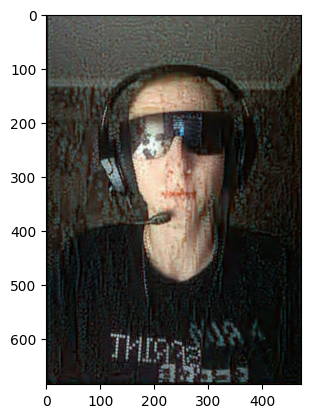

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import models
import torchvision.transforms.v2 as tfs_v2
import torch.nn as nn
import torch.optim as optim


class ModelStyle(nn.Module):
    def __init__(self):
        super().__init__()
        _model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.mf = _model.features
        self.mf.requires_grad_(False)
        self.requires_grad_(False)
        self.mf.eval()
        self.idx_out = (0, 5, 10, 19, 28, 34)
        self.num_style_layers = len(self.idx_out) - 1 # последний слой для контента

    def forward(self, x):
        outputs = []
        for indx, layer in enumerate(self.mf):
            x = layer(x)
            if indx in self.idx_out:
                outputs.append(x.squeeze(0))

        return outputs


def get_content_loss(base_content, target):
    return torch.mean( torch.square(base_content - target) )


def gram_matrix(x):
  channels = x.size(dim=0)
  g = x.view(channels, -1)
  gram = torch.mm(g, g.mT) / g.size(dim=1)
  return gram


def get_style_loss(base_style, gram_target):
    style_weights = [1.0, 0.8, 0.5, 0.3, 0.1]

    _loss = 0
    i = 0
    for base, target in zip(base_style, gram_target):
        gram_style = gram_matrix(base)
        _loss += style_weights[i] * torch.mean(torch.square(gram_style - target))
        i += 1

    return _loss


img = Image.open('content.jpg').convert('RGB')
img_style = Image.open('style.jpg').convert('RGB')

# transforms = models.VGG19_Weights.DEFAULT.transforms()
transforms = tfs_v2.Compose([tfs_v2.ToImage(),
                             tfs_v2.ToDtype(torch.float32, scale=True),
                             ])

img = transforms(img).unsqueeze(0)
img_style = transforms(img_style).unsqueeze(0)
img_create = img.clone()
img_create.requires_grad_(True)

model = ModelStyle()
outputs_img = model(img)
outputs_img_style = model(img_style)

gram_matrix_style = [gram_matrix(x) for x in outputs_img_style[:model.num_style_layers]]
content_weight = 1
style_weight = 1000
best_loss = -1
epochs = 100

optimizer = optim.Adam(params=[img_create], lr=0.01)
best_img = img_create.clone()

for _e in range(epochs):
    outputs_img_create = model(img_create)

    loss_content = get_content_loss(outputs_img_create[-1], outputs_img[-1])
    loss_style = get_style_loss(outputs_img_create, gram_matrix_style)
    loss = content_weight * loss_content + style_weight * loss_style

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    img_create.data.clamp_(0, 1)

    if loss < best_loss or best_loss < 0:
      best_loss = loss
      best_img = img_create.clone()

    print(f'Iteration: {_e}, loss: {loss.item(): .4f}')

x = best_img.detach().squeeze()
low, hi = torch.amin(x), torch.amax(x)
x = (x - low) / (hi - low) * 255.0
x = x.permute(1, 2, 0)
x = x.numpy()
x = np.clip(x, 0, 255).astype('uint8')

image = Image.fromarray(x, 'RGB')
image.save("result.jpg")

print(best_loss)
plt.imshow(x)
plt.show()